# OpenHealth Price Transparency: Public Health & Policy Briefing

This analysis evaluates healthcare market efficiency from a **Public Health** perspective, focusing on **Price Equity**, **Market Irrationality**, and the **Patient Financial Burden**.

### Key Public Health Metrics:
1.  **The Price Multiplier:** How many 'times more' do expensive providers cost vs. affordable ones?
2.  **Market Irrationality:** Is the price gap between identical services widening?
3.  **Affordability Risk:** What percentage of the market charges >2x the median price?

In [1]:
%matplotlib inline
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

BASE_URL = "http://localhost:3001/api/v1/transparency"
API_KEY = "AI4H2-PUBLIC-2023-BETA"

PROCEDURE_MAP = {
    "CPT:70551": "MRI Brain (without contrast)",
    "CPT:45378": "Colonoscopy",
    "DRG:871": "Sepsis (with Major CC)",
    "DRG:470": "Knee or Hip Replacement",
    "DRG:193": "Pneumonia (with Major CC)"
}

def fetch_data(pid):
    try:
        r = requests.get(BASE_URL, headers={"x-api-key": API_KEY}, params={"procedureId": pid})
        df = pd.DataFrame(r.json()["data"])
        if not df.empty:
            df['procedure_name'] = PROCEDURE_MAP.get(pid, pid)
        return df
    except:
        return pd.DataFrame()

full_df = pd.concat([fetch_data(pid) for pid in PROCEDURE_MAP.keys()], ignore_index=True)

## 1. The Price Multiplier (Market Irrationality Index)
In a rational market, identical services should have similar prices. Here we calculate the **Multiplier** ($90th Percentile / 10th Percentile$). 

**Public Health Interpretation:** A multiplier of 5x means the most expensive hospital is 500% more expensive than the most affordable one for the **exact same care**. 

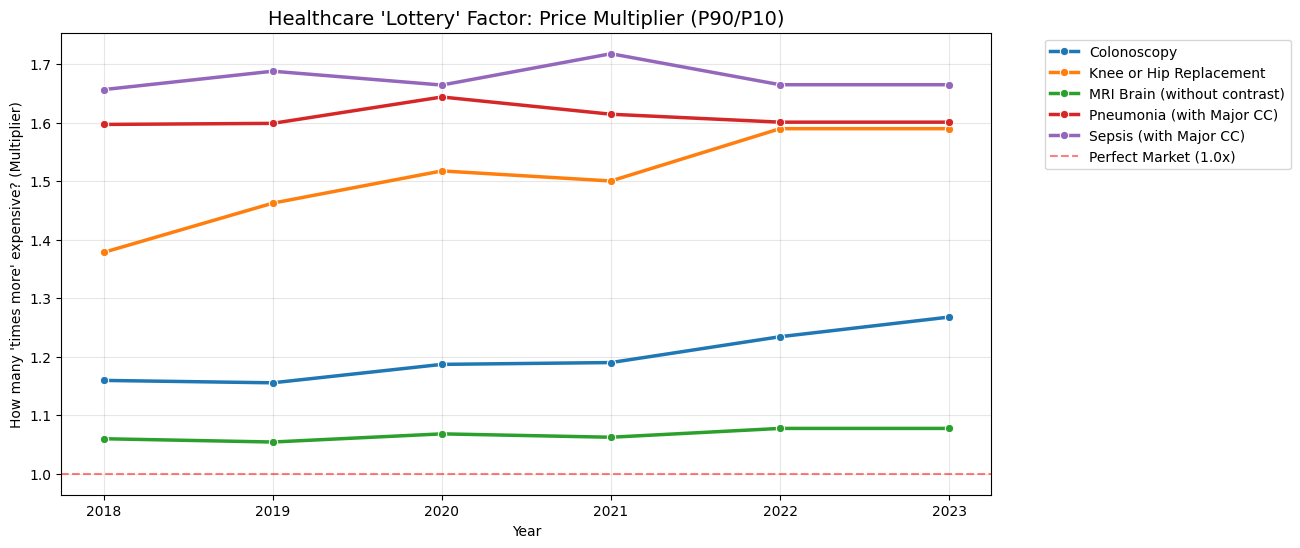

In [2]:
if not full_df.empty:
    # Calculate 10th and 90th percentiles per procedure per year
    metric_df = full_df.groupby(['procedure_name', 'source_year'])['avg_allowed'].agg([lambda x: x.quantile(0.10), lambda x: x.quantile(0.90)]).reset_index()
    metric_df.columns = ['Procedure', 'Year', 'P10', 'P90']
    
    # The Multiplier Index
    metric_df['multiplier'] = metric_df['P90'] / metric_df['P10']
    
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=metric_df, x='Year', y='multiplier', hue='Procedure', marker='o', linewidth=2.5)
    plt.axhline(1.0, color='red', linestyle='--', alpha=0.5, label='Perfect Market (1.0x)')
    
    plt.title("Healthcare 'Lottery' Factor: Price Multiplier (P90/P10)", fontsize=14)
    plt.ylabel("How many 'times more' expensive? (Multiplier)")
    plt.xlabel("Year")
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

## 2. Affordability Risk: The 'Price Gouging' Proxy
What percentage of providers are charging more than **twice the national median**? This represents the financial risk to a patient who does not have the tools to shop around.

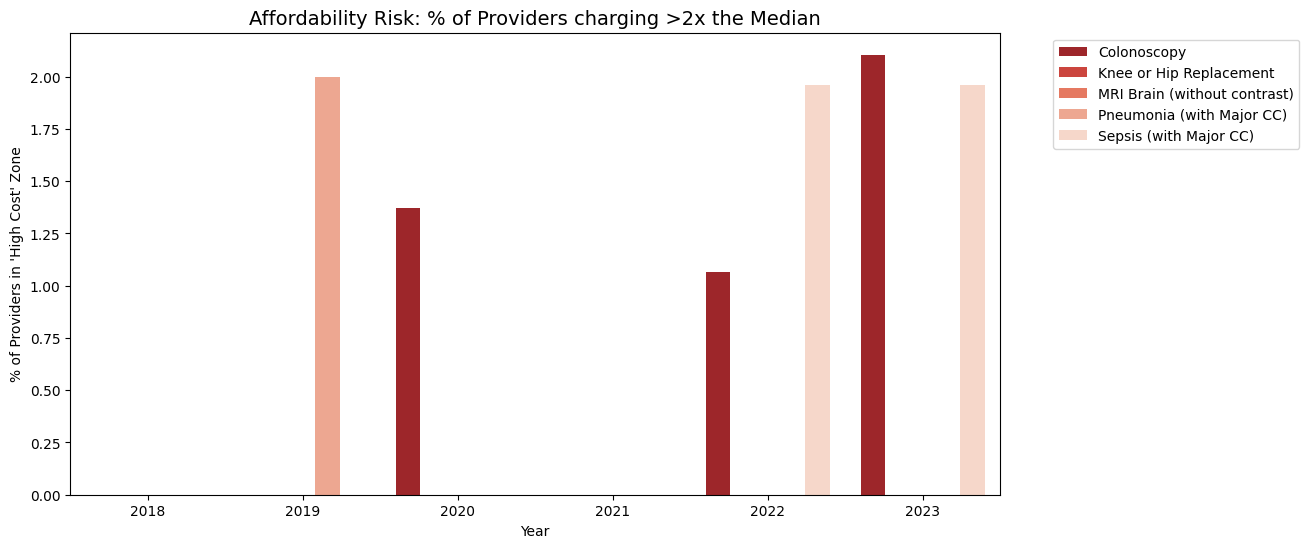

In [3]:
if not full_df.empty:
    def calc_risk(group):
        median = group.median()
        # % of providers charging > 2x the median
        return (group > (2 * median)).mean() * 100

    risk_df = full_df.groupby(['procedure_name', 'source_year'])['avg_allowed'].apply(calc_risk).reset_index()
    risk_df.columns = ['Procedure', 'Year', 'high_cost_pct']
    
    plt.figure(figsize=(12, 6))
    sns.barplot(data=risk_df, x='Year', y='high_cost_pct', hue='Procedure', palette='Reds_r')
    plt.title("Affordability Risk: % of Providers charging >2x the Median", fontsize=14)
    plt.ylabel("% of Providers in 'High Cost' Zone")
    plt.xlabel("Year")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

## 3. Real Price Inflation (Negotiated Rates)
Unlike 'Sticker Prices,' the **Negotiated Amount** is what actually leaves the healthcare system. We track the median growth to see the real cost burden on the public.

In [4]:
if not full_df.empty:
    inflation = full_df.groupby(['procedure_name', 'source_year'])['avg_allowed'].median().reset_index()
    inflation['pct_change'] = inflation.groupby('procedure_name')['avg_allowed'].pct_change() * 100
    
    print("### Median Negotiated Price Inflation (% Year-over-Year)")
    display(inflation.pivot(index='procedure_name', columns='source_year', values='pct_change').round(2))

### Median Negotiated Price Inflation (% Year-over-Year)


source_year,2018,2019,2020,2021,2022,2023
procedure_name,,,,,,
Colonoscopy,NaN,-1.05,-3.42,-0.41,-3.77,0.12
Knee or Hip Replacement,NaN,0.79,2.30,-0.12,-1.79,0.00
MRI Brain (without contrast),NaN,1.39,-4.97,-1.21,-1.97,0.00
Pneumonia (with Major CC),NaN,-1.21,3.64,2.46,0.49,0.00
Sepsis (with Major CC),NaN,3.15,7.09,3.33,0.42,0.00
